# Describing Data

_text goes here_

In [71]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# load data into datframe
df = pd.read_csv("../datasets/Effectiveness_Exam_To_Sleep_Quality.csv")

In [4]:
df.head()

,age,gender,course,study_hours,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,yes,9.8,poor,coaching,low,moderate,43.7


Let's starting asking questions!!!

**What is the average amount of hours students spend studying?**

In [5]:
study_hours = df['study_hours']
mean_study_hour = study_hours.mean()
median_study_hour = study_hours.median()
print(f"The mean study hour is {round(mean_study_hour)} hours")

The mean study hour is 4 hours


Let's take at look the distribution of study hours to make sense of this information.

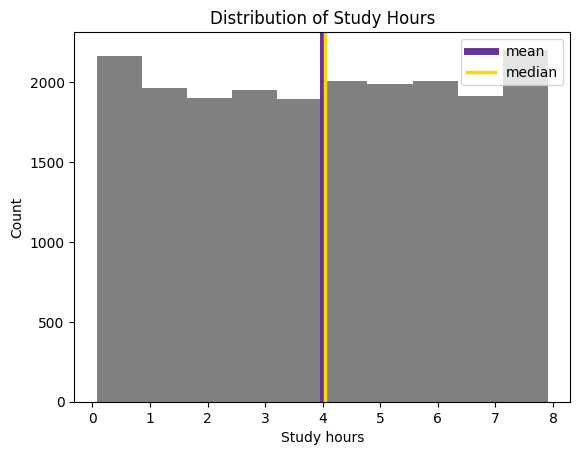

In [6]:
plt.hist(x=study_hours, color='gray')

# add labels
plt.xlabel("Study hours")
plt.ylabel("Count")
plt.title("Distribution of Study Hours")

# add lines to display mean and median
plt.axvline(mean_study_hour, color='rebeccapurple', label='mean', linewidth=5)
plt.axvline(median_study_hour, color='gold', label='median', linewidth=2.5)
plt.legend()

plt.show()

From this histogram, it appears that we have a uniform distribution. The mean and the median are also centered at the middle. The histogram shows that study hours are distributed fairly evenly between 0 and 8 hours rather than clustering around the mean. 

This shows that the average of this dataset represents the midpoint of the range rather than a dominant study pattern among students.  While 4 hours represents the centre of the distribution, students in the dataset exhibit a wide range of study habits.

**What study method is mostly used?**

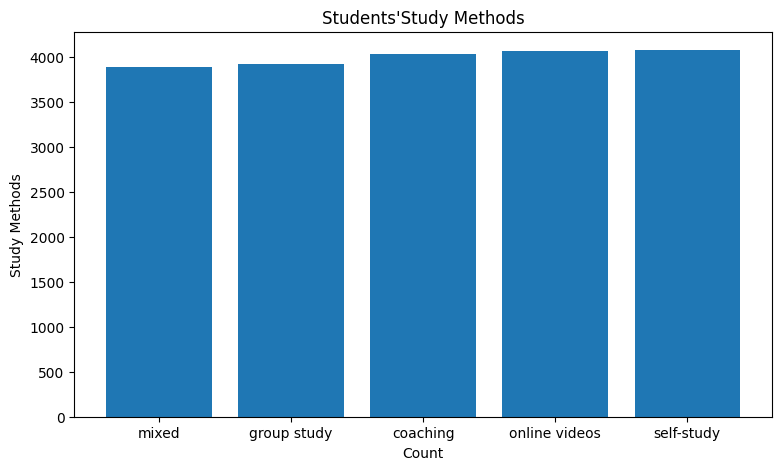

In [65]:
study_count = df['study_method'].value_counts().sort_values()
plt.figure(figsize=(9, 5))
plt.bar(x=study_count.index, height=study_count)

plt.ylabel('Study Methods')
plt.xlabel('Count')
plt.title("Students'Study Methods")
plt.show()

From the visualization, we can tell that the most used study method by students in this dataset is **self study**.

But overall, the students use a wide variety of study methods with no single method strongly dominating the dataset.

**Which study method leads to the highest exam score?**

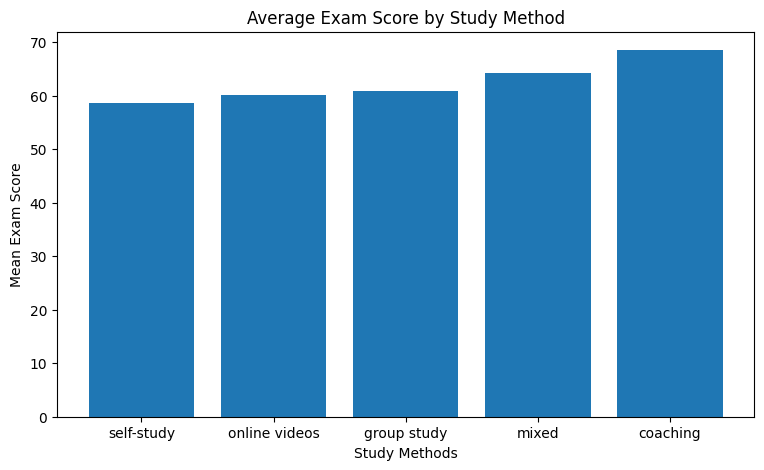

In [68]:
grpd_study_mthd = df.groupby('study_method').agg(mean_exam_score=('exam_score', 'mean')).sort_values(by='mean_exam_score')
grpd_study_mthd.shape

plt.figure(figsize=(9, 5))
plt.bar(x=grpd_study_mthd.index, height=grpd_study_mthd['mean_exam_score'])

# label axis
plt.xlabel('Study Methods')
plt.ylabel('Mean Exam Score')
plt.title('Average Exam Score by Study Method')

plt.show()

Even though **self study** is the most used study method, in this dataset, **coaching** has proven to be the study method with the most impact on the exam scores.

In [96]:

# df[['study_method', 'exam_score']].sort_values('study_method').groupby('study_method')
df.groupby('study_method', as_index=True)['exam_score'].apply(lambda x: df['exam_score'])

study_method       
coaching      0        58.9
              1        54.8
              2        90.3
              3        29.7
              4        43.7
                       ... 
self-study    19995    86.5
              19996    60.9
              19997    64.5
              19998    79.0
              19999    71.0
Name: exam_score, Length: 100000, dtype: float64